In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"C:\Users\User\Desktop\IEP PROJECTS\Mall_customers.csv")

In [3]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0
...,...,...,...,...,...
995,1995,M,80.0,133.3,1.0
996,1996,M,44.0,82.6,40.0
997,1997,F,46.0,67.7,26.0
998,1998,F,28.0,45.7,59.0


## Data Exploration

In [4]:
df.shape

(1000, 5)

In [5]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [6]:
df.dtypes

CustomerID                  int64
Gender                     object
Age                       float64
Annual Income (k$)        float64
Spending Score (1-100)    float64
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


In [8]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


## Data Cleaning

In [9]:
#Null values

In [10]:
df.isnull().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

In [11]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

In [12]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

In [13]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [14]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

In [15]:
df["Annual Income (k$)"] = df["Annual Income (k$)"].fillna(df["Annual Income (k$)"].mean())

In [16]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    6
dtype: int64

In [17]:
df["Spending Score (1-100)"] = df["Spending Score (1-100)"].fillna(df["Spending Score (1-100)"].mean()) 

In [18]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### Removing duplicate values

In [19]:
print(df.duplicated().sum())

0


## Outlier Analysis

In [20]:
def detect_outliers(column):
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    print(column, "Outliers:", len(outliers))

detect_outliers("Age")
detect_outliers("Annual Income (k$)")
detect_outliers("Spending Score (1-100)")

Age Outliers: 72
Annual Income (k$) Outliers: 0
Spending Score (1-100) Outliers: 0


Outlier detection was performed using the IQR method. Although several observations were identified as statistical outliers in the Age column, they represent valid customer age values and were retained to preserve the natural distribution of the dataset.

In [21]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

age_outliers = df[(df["Age"] < lower_bound) | (df["Age"] > upper_bound)]

age_outliers

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
209,1209,F,66.0,98.9,1.0
757,1757,F,76.0,125.5,1.0
767,1767,F,66.0,108.2,1.0
775,1775,M,69.0,91.8,5.0
776,1776,M,68.0,95.7,14.0
...,...,...,...,...,...
982,1982,F,78.0,122.6,1.0
983,1983,M,78.0,115.1,1.0
991,1991,M,66.0,105.2,12.0
995,1995,M,80.0,133.3,1.0


### Customer Filtering Analysis

In [22]:
# Filter male and female customers
male_customers = df[df["Gender"] == "M"]
female_customers = df[df["Gender"] == "F"]

print("Male Customers")
display(male_customers.head())

print("Female Customers")
display(female_customers.head())

Male Customers


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
5,1005,M,33.0,36.7,73.0
9,1009,M,39.0,48.6,61.0
10,1010,M,31.0,21.2,52.0


Female Customers


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0
6,1006,F,48.0,90.4,34.0
7,1007,F,41.0,74.8,35.0


#### The mall attracts both male and female customers, indicating a balanced customer base.

In [23]:
# Customers who spend more
high_spenders = df[df["Spending Score (1-100)"] > 70]

high_spenders.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
5,1005,M,33.0,36.7,73.0
13,1013,F,20.0,15.0,78.0
38,1038,F,24.0,27.1,73.0
46,1046,F,31.0,30.7,79.0
49,1049,F,21.0,20.0,71.0


#### Most customers fall in the young to middle-aged group, suggesting that the mall is popular among working-age shoppers.

In [24]:
# Customers with high income
high_income = df[df["Annual Income (k$)"] > 70]

high_income.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
6,1006,F,48.0,90.4,34.0
7,1007,F,41.0,74.8,35.0
20,1020,F,47.0,89.0,23.0


#### Customer annual income varies widely, indicating that the mall serves shoppers from different economic backgrounds.

In [25]:
# Customers with high income and high spending
premium_customers = df[
    (df["Annual Income (k$)"] > 60) &
    (df["Spending Score (1-100)"] > 60)
]

display(premium_customers.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
75,1075,F,42.0,62.8,62.0
352,1352,M,42.0,74.6,62.0
913,1913,F,43.0,62.5,64.0


#### Spending scores range from high to low, showing that customer purchasing behavior differs significantly.

In [26]:
# Top spending customers
top_spenders = df.sort_values(by="Spending Score (1-100)", ascending=False)

top_spenders.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
382,1382,M,18.0,20.0,92.0
634,1634,F,27.0,16.6,83.0
648,1648,F,33.0,47.9,82.0
100,1100,F,24.0,27.6,81.0
852,1852,F,33.0,32.4,80.0
325,1325,F,25.0,32.0,79.0
46,1046,F,31.0,30.7,79.0
568,1568,M,20.0,15.0,79.0
533,1533,M,25.0,20.5,78.0
713,1713,M,38.0,48.3,78.0


#### The relationship between income and spending reveals distinct customer groups, which helps identify potential customer segments for clustering.

In [27]:
# Highest income customers
top_income_customers = df.sort_values(by="Annual Income (k$)", ascending=False)

top_income_customers.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
907,1907,M,77.0,144.1,1.0
995,1995,M,80.0,133.3,1.0
874,1874,M,79.0,132.0,1.0
784,1784,F,77.0,129.6,1.0
887,1887,M,78.0,129.1,1.0
847,1847,F,79.0,129.0,1.0
890,1890,M,80.0,128.9,1.0
876,1876,F,76.0,128.9,1.0
971,1971,F,76.0,127.9,1.0
931,1931,M,72.0,127.7,1.0


#### Customers with the highest income are mostly older individuals, but they tend to spend very little in the mall.

## DATA VISUALIZATION

### Data quality check

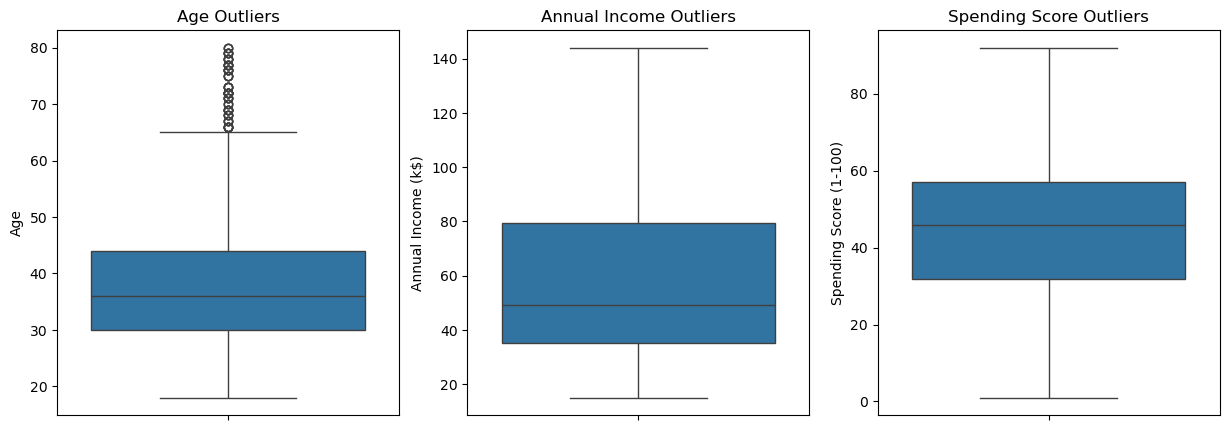

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(y=df["Age"])
plt.title("Age Outliers")

plt.subplot(1,3,2)
sns.boxplot(y=df["Annual Income (k$)"])
plt.title("Annual Income Outliers")

plt.subplot(1,3,3)
sns.boxplot(y=df["Spending Score (1-100)"])
plt.title("Spending Score Outliers")

plt.show()

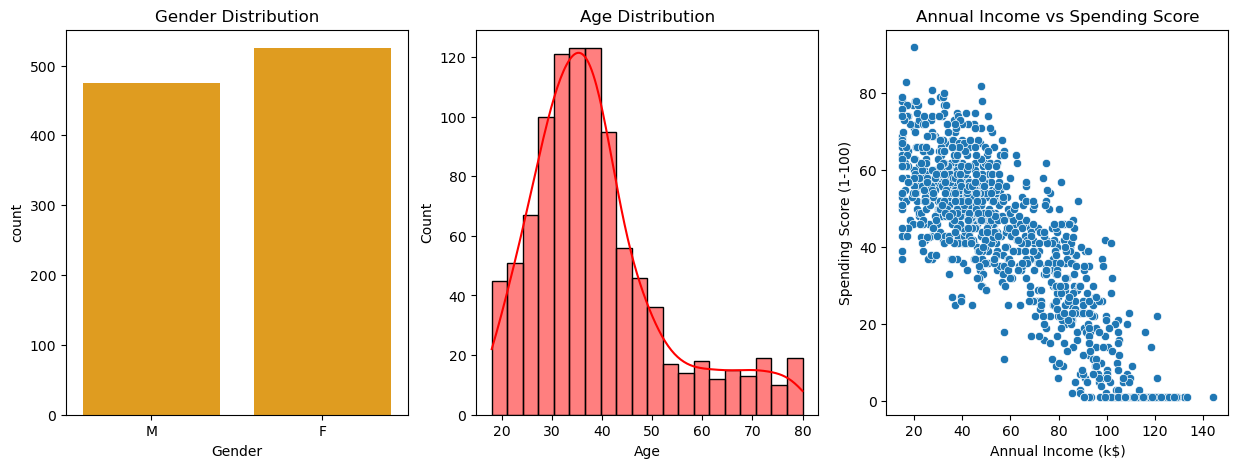

In [29]:
plt.figure(figsize=(15,5))

#Gender Distribution
plt.subplot(1,3,1)
sns.countplot(x="Gender",color = "orange", data=df)
plt.title("Gender Distribution")

#Age Distribution
plt.subplot(1,3,2)
sns.histplot(df["Age"], bins=20,color = "red", kde=True)
plt.title("Age Distribution")

#Income vs Spending score
plt.subplot(1,3,3)
sns.scatterplot(x="Annual Income (k$)", y="Spending Score (1-100)", data=df)
plt.title("Annual Income vs Spending Score")

plt.show()

## Data Story Telling